_Copyright (C) 2024 Jagger Alexander_

_This program is free software: you can redistribute it and/or modify it as published._

_This program is distributed in the hope that it will be informative, but without any warranty; without even the implied warranty of merchantability or fitness for a particular purpose._

### Process climatology data for ML-based heat wave prediction

1. Import necessary packages 
2. Import your downloaded climatology
3. Check for missing data
4. Create heat threshold based on climatology
5. Export file for use in prediction
6. Create plots for visualization

In [3]:
#1. Import necessary packages
#---

#Install as needed with !pip install packagename
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
#2. Import your downloaded climatology
#---

#Add user path here
file_path = r"C:\Users\17753\Documents\Clim.csv" 

# Check if the file exists and define variable
if os.path.exists(file_path):
    clim_data = pd.read_csv(file_path)
    #Optionally, see full dataframe
    #print(clim_data.head()) 
else:
    print(f"File not found: {file_path}")

# Keeping only the 'TMAX' and 'DATE' columns
clim_data = clim_data[['DATE', 'TMAX']]

# Head the filtered dataframe
print("Climatology data frame looks like: \n", clim_data.head())


Climatology data frame looks like: 
          DATE  TMAX
0  1993-01-01   NaN
1  1993-01-02   NaN
2  1993-01-03   NaN
3  1993-01-04  17.2
4  1993-01-05  11.7


In [5]:
#3. Check for missing data
#---

#Ensure DATE is in datetime format
clim_data['DATE'] = pd.to_datetime(clim_data['DATE'])

# Extract day of year from 'DATE'
clim_data['DAY_OF_YEAR'] = clim_data['DATE'].dt.strftime('%m-%d')

# Filter for rows with no data in 'TMAX'
na_counts_by_day = clim_data[clim_data['TMAX'].isna()]

# Group by 'DAY_OF_YEAR' and count NaNs
na_counts_by_day = na_counts_by_day.groupby('DAY_OF_YEAR').size()

print("Number of 'na's by each day of the year: \n", na_counts_by_day)
print("\n Max number of 'na' counts for any given day =", max(na_counts_by_day))

Number of 'na's by each day of the year: 
 DAY_OF_YEAR
01-01    2
01-02    2
01-03    1
01-06    1
01-07    1
        ..
12-18    1
12-24    1
12-25    1
12-26    1
12-31    1
Length: 73, dtype: int64

 Max number of 'na' counts for any given day = 3


In [6]:
#4. Create heat threshold based on climatology
#---

# Extract month and day from the 'DATE' column
clim_data['MONTH'] = clim_data['DATE'].dt.month
clim_data['DAY'] = clim_data['DATE'].dt.day

# Group by 'MONTH' and 'DAY' to calculate daily statistics
daily_clim = clim_data.groupby(['MONTH', 'DAY'])['TMAX'].agg(['mean', 'std'])

# Calculate the tmax threshold, currently set to 85th percentile
percentile = .85 #adjust as desired
z_score = norm.ppf(percentile)
daily_clim['heat_threshold'] = daily_clim['mean'] + z_score * daily_clim['std']

# Reset index to have 'MONTH' and 'DAY' as columns
daily_clim.reset_index(inplace=True)

# Rename the columns
daily_clim.rename(columns={
    "MONTH": "month",
    "DAY": "day",
    "mean": "tmax_clim",
    "std": "tmax_std",
    "heat_threshold": "heat_threshold"
}, inplace=True)

# Apply a 14-day moving average to smooth both tmax_clim and heat_threshold
concat_length = 7  
# The number of days to wrap around for smoothing, for a 14-day window, we take 7 days from each end
daily_clim_extended = pd.concat([
    daily_clim[-concat_length:],  # Take the last 3 days of the year (December)
    daily_clim,
    daily_clim[:concat_length]  # Take the first 3 days of the year (January)
])

# Step 2: Apply the moving average to both tmax_clim and t90_clim on the extended data
daily_clim_extended['tmax_clim_smoothed'] = daily_clim_extended['tmax_clim'].rolling(window=14, center=True).mean()
daily_clim_extended['heat_threshold_smoothed'] = daily_clim_extended['heat_threshold'].rolling(window=14, center=True).mean()

# Step 3: Trim the extended dataframe to the original size by removing the extra rows
daily_clim = daily_clim_extended[concat_length:-concat_length].reset_index(drop=True)

print(daily_clim.head())

   month  day  tmax_clim  tmax_std  heat_threshold  tmax_clim_smoothed  \
0      1    1  15.840000  7.990672       24.121799           16.796450   
1      1    2  14.161538  7.553440       21.990176           16.898146   
2      1    3  16.464286  6.851127       23.565022           17.016628   
3      1    4  17.048276  6.234445       23.509862           16.918484   
4      1    5  17.303448  6.086841       23.612053           16.936464   

   heat_threshold_smoothed  
0                23.631252  
1                23.702482  
2                23.784451  
3                23.735573  
4                23.791303  


In [7]:
#5. Export file for use in prediction
#---

# Save the dataframe to a CSV file
file_path = r"C:\Users\17753\Documents\Ch1Data\processed_climatology.csv"
daily_clim.to_csv(file_path, index=False)

print("File saved successfully at", file_path)

File saved successfully at C:\Users\17753\Documents\Ch1Data\processed_climatology.csv


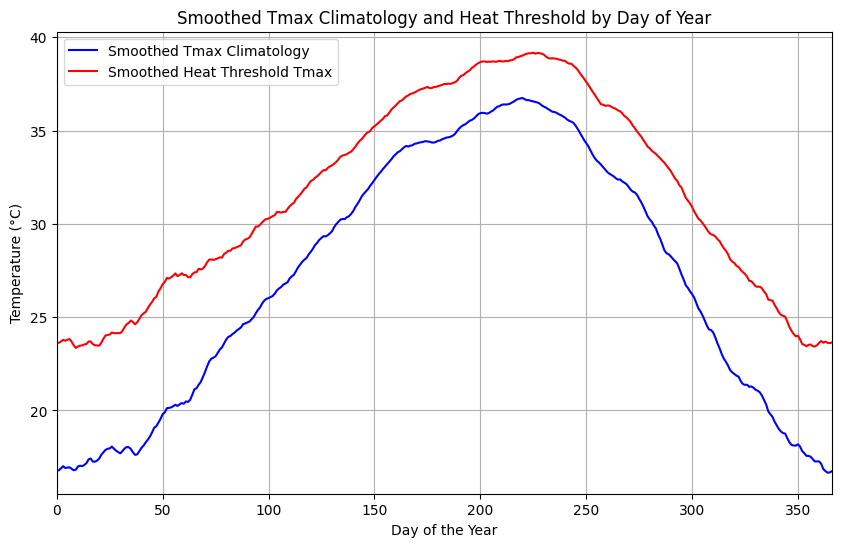

In [8]:
#6. Create plots for visualization
#---

#Create a new column for 'day_of_year'
daily_clim['year'] = [0]*len(daily_clim)
daily_clim['day_of_year'] = pd.to_datetime(daily_clim[['year', 'month', 'day']].assign(year=2020), errors='coerce').dt.dayofyear

# Plotting the smoothed tmax_clim and t90_clim
plt.figure(figsize=(10, 6))

plt.plot(daily_clim['day_of_year'], daily_clim['tmax_clim_smoothed'], label='Smoothed Tmax Climatology', color='blue', linestyle='-')
plt.plot(daily_clim['day_of_year'], daily_clim['heat_threshold_smoothed'], label='Smoothed Heat Threshold Tmax', color='red', linestyle='-')
plt.xlim(0,366)

# Adding labels and title
plt.xlabel('Day of the Year')
plt.ylabel('Temperature (°C)')
plt.title('Smoothed Tmax Climatology and Heat Threshold by Day of Year')
plt.legend()

# Display the plot
plt.grid(True)
plt.show()